In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:


vcf_file = "ERR605261.ann.vcf"

rows = []

with open(vcf_file, "r") as f:
    for line in f:
        if line.startswith("#"):
            continue

        fields = line.strip().split("\t")

        chrom = fields[0]
        pos = fields[1]
        ref = fields[3]
        alt = fields[4]
        qual = fields[5]
        info = fields[7]

        impact = ""
        effect = ""
        gene = ""

        if "ANN=" in info:
            ann = info.split("ANN=")[1].split(";")[0]
            first = ann.split(",")[0]
            ann_fields = first.split("|")

            if len(ann_fields) >= 5:
                effect = ann_fields[1]
                impact = ann_fields[2]
                gene = ann_fields[3]

        rows.append([chrom, pos, ref, alt, qual, impact, effect, gene])

df = pd.DataFrame(
    rows,
    columns=[
        "Chromosome",
        "Position",
        "REF",
        "ALT",
        "QUAL",
        "Impact",
        "Effect",
        "Gene",
    ],
)

df.to_csv("variant_table.csv", index=False)

print(df.head())
print("Total Variants:", len(df))

  Chromosome Position REF ALT    QUAL    Impact                   Effect  \
0          1    31071   A   G  154.14  MODIFIER    upstream_gene_variant   
1          1    33667   A   G   66.32  MODIFIER    upstream_gene_variant   
2          1    35239   A   C   77.32  MODIFIER    upstream_gene_variant   
3          1    41890   T   C  200.96  MODIFIER  downstream_gene_variant   
4          1    49412   G   T  151.14  MODIFIER        intergenic_region   

                Gene  
0       Os01g0100650  
1               SPL1  
2               SPL1  
3               SPL1  
4  SPL1-Os01g0101150  
Total Variants: 350472


In [4]:
print(df.shape)

(350472, 8)


In [5]:
print(df.columns)

Index(['Chromosome', 'Position', 'REF', 'ALT', 'QUAL', 'Impact', 'Effect',
       'Gene'],
      dtype='object')


In [6]:
print(df.dtypes)

Chromosome    object
Position      object
REF           object
ALT           object
QUAL          object
Impact        object
Effect        object
Gene          object
dtype: object


In [7]:
print(df.isnull().sum())

Chromosome    0
Position      0
REF           0
ALT           0
QUAL          0
Impact        0
Effect        0
Gene          0
dtype: int64


In [8]:
impact_counts = df["Impact"].value_counts()
print(impact_counts)

Impact
MODIFIER    324488
MODERATE     12741
LOW          11832
HIGH          1411
Name: count, dtype: int64


In [9]:
top_genes = df["Gene"].value_counts().head(20)
print(top_genes)

Gene
Os04g0261400-Os04g0266400    1711
                              820
OsNCED2-Sci1                  810
Os05g0173800-Os05g0175450     566
Os10g0382600-Os_F0664         530
OsABCG30-Os12g0414500         477
Os04g0259200-Os04g0261400     461
Os12g0297500-Os12g0298600     455
Os06g0276300-Os06g0277850     449
Os04g0231800-OsPIP2           435
OsERF#128-OsFbox192           431
Os09g0290900-Os09g0292300     415
Os10g0173800-OsWAK107         390
Os09g0316400-Os09g0317700     375
Os08g0302100-BIP126           360
OsDRB1c-Os05g0309000          359
Os08g0276400-OsCCR            352
Os09g0287500-Os09g0289100     349
Os03g0560050-Os03g0561283     346
Os10g0448000-Os10g0449400     343
Name: count, dtype: int64


In [10]:
effect_counts = df["Effect"].value_counts().head(20)
print(effect_counts)

Effect
upstream_gene_variant                             126827
intergenic_region                                 115268
downstream_gene_variant                            53260
intron_variant                                     13634
missense_variant                                   12005
3_prime_UTR_variant                                10458
synonymous_variant                                  9825
5_prime_UTR_variant                                 4773
splice_region_variant&intron_variant                 974
frameshift_variant                                   956
5_prime_UTR_premature_start_codon_gain_variant       708
non_coding_transcript_exon_variant                   260
disruptive_inframe_deletion                          190
splice_region_variant                                185
stop_gained                                          169
conservative_inframe_insertion                       164
conservative_inframe_deletion                        138
disruptive_inframe_inser

In [11]:
chorm_count = df["Chromosome"].value_counts().sort_index()
print(chorm_count)

Chromosome
1                33927
10               39621
11               30828
12               32728
2                24806
3                16870
4                46783
5                22296
6                27425
7                18897
8                36600
9                18787
AC155918            11
AC156495            26
AC160949           161
AC174930            19
AP008246           171
AP008247            42
Mt                  82
Pt                   2
Syng_TIGR_002        1
Syng_TIGR_004       43
Syng_TIGR_010        6
Syng_TIGR_012       28
Syng_TIGR_014       27
Syng_TIGR_016       48
Syng_TIGR_021        5
Syng_TIGR_023       50
Syng_TIGR_026       14
Syng_TIGR_027        2
Syng_TIGR_028       14
Syng_TIGR_029        9
Syng_TIGR_030       18
Syng_TIGR_032       92
Syng_TIGR_035       14
Syng_TIGR_036        1
Syng_TIGR_044        9
Syng_TIGR_045        4
Syng_TIGR_050        5
Name: count, dtype: int64


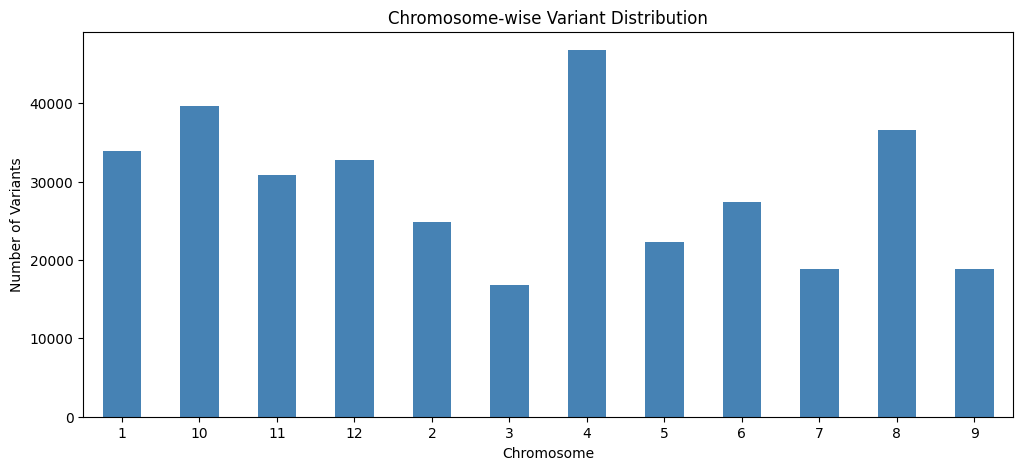

In [12]:

df["Chromosome"] = df["Chromosome"].astype(str)

chrom_df = df[df["Chromosome"].isin([str(i) for i in range(1, 15)])]

chrom_counts = chrom_df["Chromosome"].value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
chrom_counts.plot(kind="bar", color="steelblue")

plt.title("Chromosome-wise Variant Distribution")
plt.xlabel("Chromosome")
plt.ylabel("Number of Variants")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0)

plt.show()

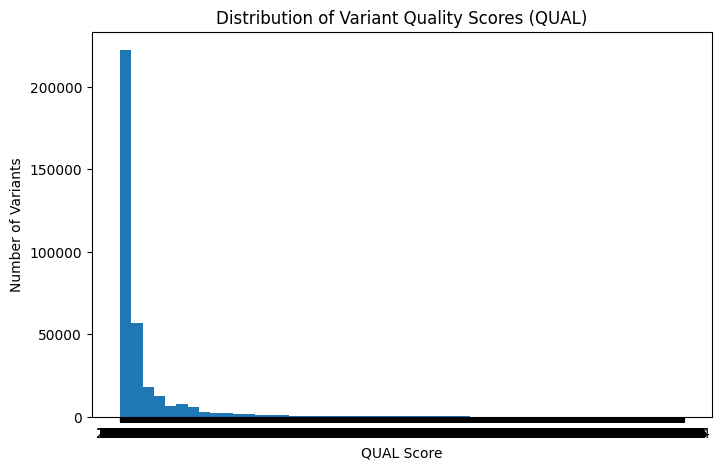

In [13]:


plt.figure(figsize=(8,5))

plt.hist(df["QUAL"].dropna(), bins=50)

plt.title("Distribution of Variant Quality Scores (QUAL)")
plt.xlabel("QUAL Score")
plt.ylabel("Number of Variants")

plt.show()

In [14]:
print(df["QUAL"].describe())

count     350472
unique      3198
top        78.32
freq       56655
Name: QUAL, dtype: object


In [15]:
high_quality = df[df["QUAL"] >= 30]

print("High Quality Variants:", len(high_quality))
print("Percentage:", round(len(high_quality)/len(df)*100,2), "%")

TypeError: '>=' not supported between instances of 'str' and 'int'

In [16]:
high_df = df[df["Impact"] == "HIGH"]

top_high_genes = high_df["Gene"].value_counts().head(20)

print(top_high_genes)

Gene
Os11g0704100    16
Os08g0150150    10
OsFbox607        9
Os04g0462900     9
Os01g0781100     9
Os04g0118700     8
OsRLCK131        8
Os10g0450400     8
Os10g0161400     7
Os09g0558600     7
OsCrRLK1L4       7
Os04g0538166     6
Os04g0687150     6
Os04g0162800     6
Os08g0202300     6
Os11g0598500     6
Os04g0153000     6
Os11g0540600     6
Os04g0111100     6
OsEFCAX2         6
Name: count, dtype: int64


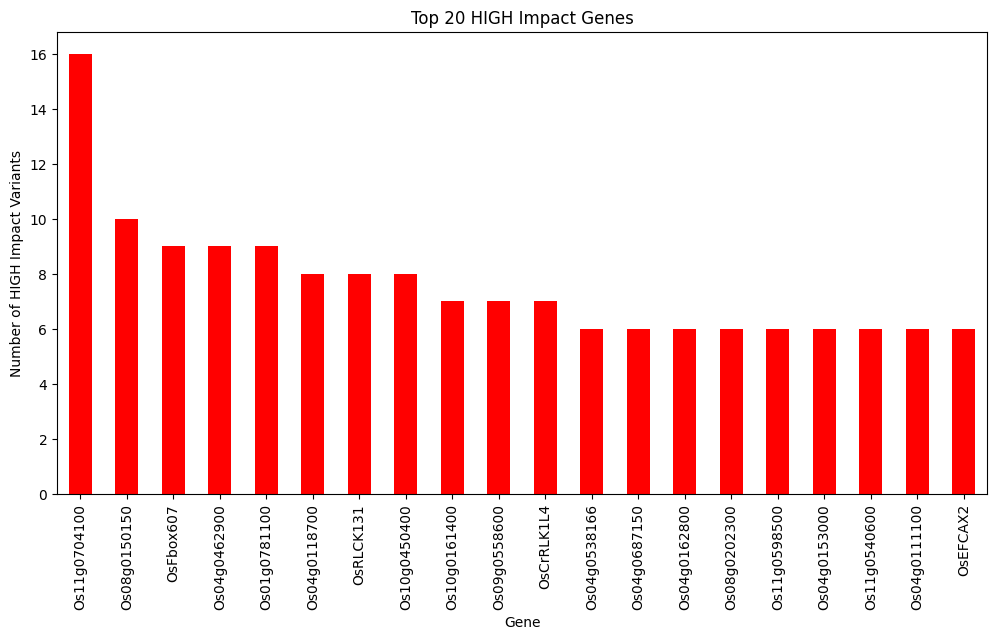

In [17]:


plt.figure(figsize=(12,6))

top_high_genes.plot(kind="bar", color="red")

plt.title("Top 20 HIGH Impact Genes")
plt.xlabel("Gene")
plt.ylabel("Number of HIGH Impact Variants")

plt.xticks(rotation=90)

plt.show()

In [18]:
moderate_df = df[df["Impact"] == "MODERATE"]

top_moderate = moderate_df["Gene"].value_counts().head(20)

print(top_moderate)

Gene
Os08g0150150    86
OsRLCK25        74
LRK2            74
Os11g0704100    65
OsRLK5          62
Os11g0481150    52
Os10g0161400    44
Os09g0561000    42
Os07g0580700    39
Os11g0628000    38
Os10g0375600    37
OsRLCK20        37
Os11g0640300    36
OsWAK96/97      35
Os11g0598500    35
Os10g0116200    35
Os04g0154000    32
WAK14           32
OsRLCK148       32
Os09g0283600    32
Name: count, dtype: int64


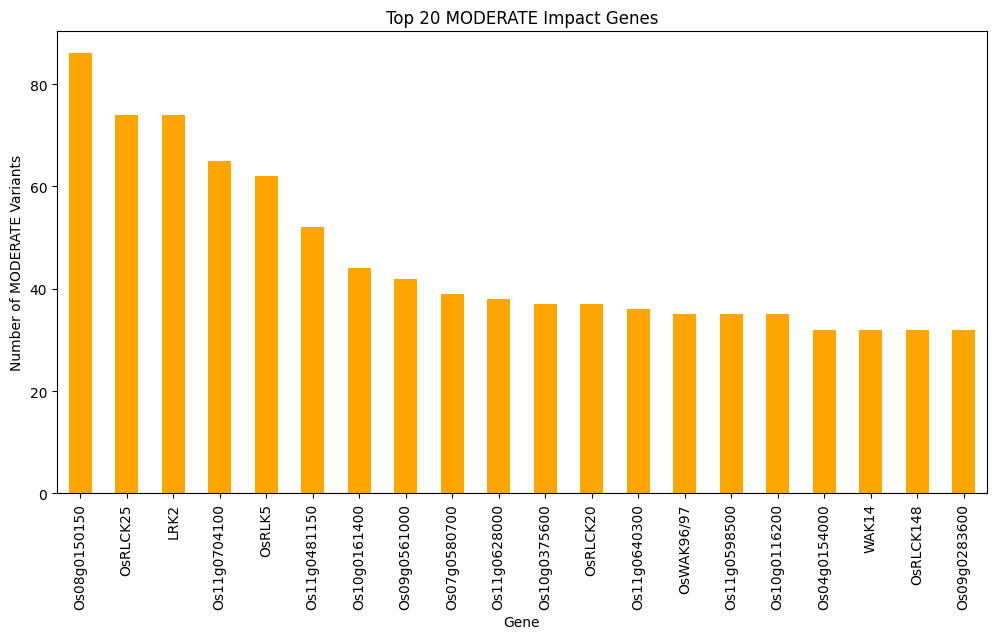

In [19]:
plt.figure(figsize=(12,6))

top_moderate.plot(kind="bar", color="orange")

plt.title("Top 20 MODERATE Impact Genes")
plt.xlabel("Gene")
plt.ylabel("Number of MODERATE Variants")

plt.xticks(rotation=90)

plt.show()

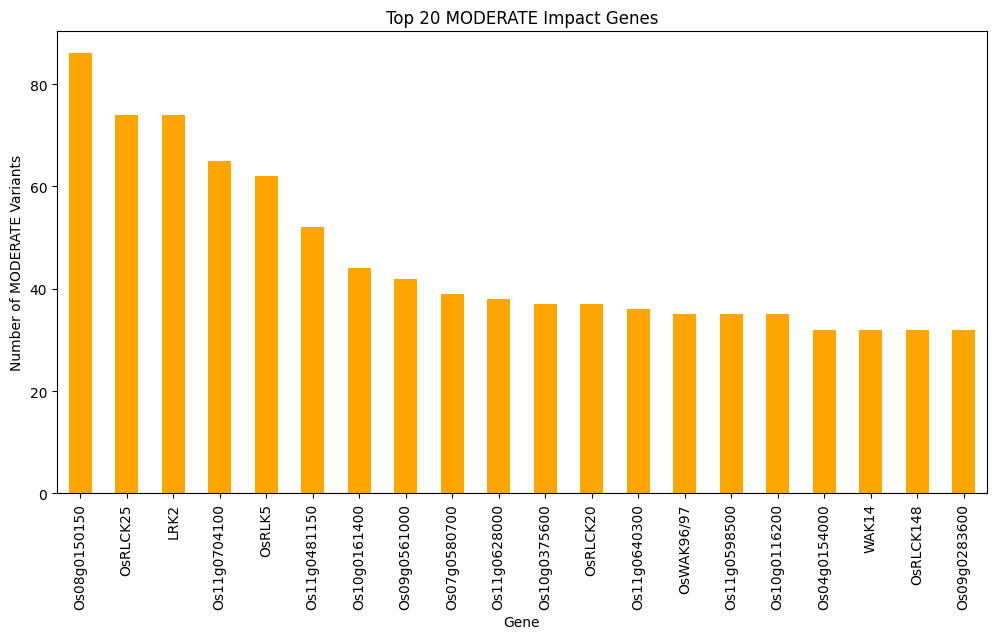

In [20]:
plt.figure(figsize=(12,6))

top_moderate.plot(kind="bar", color="orange")

plt.title("Top 20 MODERATE Impact Genes")
plt.xlabel("Gene")
plt.ylabel("Number of MODERATE Variants")

plt.xticks(rotation=90)

plt.show()